# What is Map‑Reduce with LLMs?
You use an LLM to:

    MAP → break a big input into smaller chunks
    PROCESS → run the LLM on each chunk in parallel
    REDUCE → merge all LLM outputs into a final answer

#### Goal: build an LLM agent that uses map-reduce and send API to summerize an article paragraphs from wikipedia. Use LLM to classify the doc into paragraphs and summarise.

*Imagine you have a long article split into 4 paragraphs:*

Code :
```
[p1, p2, p3, p4]
```
You want the LLM to summarize each paragraph in parallel, then combine them.

#### Map‑reduce does:

`Map:  `
For each paragraph → send to LLM

`Reduce:  `
Combine all summaries → final summary

In [1]:
#Set API from envirnment
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

In [2]:
# creat llm
from google import genai
from langchain_google_genai import ChatGoogleGenerativeAI

client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

llm = ChatGoogleGenerativeAI( model= "gemini-flash-lite-latest" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content

[{'type': 'text',
  'text': 'Today is **Wednesday, May 22, 2024**.',
  'extras': {'signature': 'EjQKMgEMOdbHRGUQbN4r+MV5ZJ5nwyr6rO7+FCCCi9YD3M1Tx5vQTFEjyke9f1NllleZruZp'}}]

In [56]:
# define class
from typing_extensions import TypedDict , List , Annotated
from operator import add
from langchain_community.document_loaders import WikipediaLoader


class overallState(TypedDict):
    question: str
    Doc:str
    paragraph_list: List[str]
    summarized_list: Annotated[List[str] , add]
    final_summary:str


# node functions
#get wikipediaa doc for a question
def get_doc(state:overallState):
    ''' extract document via wikipedia'''
    
    doc = WikipediaLoader(query=state['question'], load_max_docs=1, doc_content_chars_max=5000).load()
    return {'Doc' : doc[0].metadata['summary'] }

# classify into paragraphs

# create a structured output for LLM
from  pydantic import BaseModel

class list_prompt(BaseModel):
    para_list: List[str]

def set_para(state):
    ''' classify the doc into paragraphs'''
    prompt = f"classify the following doc into a list of 4 paragraphs. doc = {state['Doc']}. Create a list"
    response = llm.with_structured_output(list_prompt).invoke(prompt)
    return {'paragraph_list': response.para_list }

# map-reduce using Send API 

# summarize the paragraphs seperately
from langgraph.types import Send

def map_summarize(state):
    para_list = state['paragraph_list']
    return [Send('summarize' , {'paragraph' : paragraph}) for paragraph in para_list]

# create a summarize node
def summarize(state):
    para = state['paragraph']
    summary_prompt = " Just summerize the paragraph given {} in 3 sentences without providing the guide.".format(para)
    response  = llm.invoke(summary_prompt)
    return {'summarized_list': [response.content[-1]['text']] }

# reduce to one final summary
def reduce_final_summary(state):
    '''reduce the partial summaries into one final summary '''
    
    partial_summary = state['summarized_list']
    final_sum_prompt = f"combine the list of partial summaries into one final summary without explaining.{partial_summary}"
    response = llm.invoke(final_sum_prompt)
    return {'final_summary' : response.content[-1]['text'] }

    

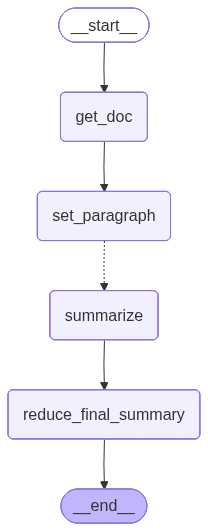

In [57]:
# build graph
from langgraph.graph import StateGraph, START , END

builder = StateGraph(overallState)

# add nodes
builder.add_node('get_doc' , get_doc)
builder.add_node('set_paragraph' , set_para)
builder.add_node('summarize' , summarize)
builder.add_node('reduce_final_summary' , reduce_final_summary)

# add flow
builder.set_entry_point('get_doc')
builder.add_edge('get_doc', 'set_paragraph')
builder.add_conditional_edges('set_paragraph' , map_summarize, ['summarize'])
builder.add_edge('summarize', 'reduce_final_summary')
builder.add_edge('reduce_final_summary', END)

# compile
graph = builder.compile()

graph


In [58]:
question = "what is AI?"
chunks = []
for chunk in graph.stream({"question": question } , stream_mode="updates"): 
    chunks.append(chunk)
    print(chunk)
    print("-"*40)
    

{'get_doc': {'Doc': "Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.\nHigh-profile applications of AI include advanced web search engines, chatbots, virtual assistants, autonomous vehicles, and play and analysis in strategy games (e.g., chess and Go). Since the 2020s, generative AI has become widely available to generate images, audio, and videos from text prompts.\nThe traditional goals of AI research include learning, reasoning, knowledge representation, planning, natural language processing, and perception, as well as support for robotics. To rea

In [60]:
chunks[-1]

{'reduce_final_summary': {'final_summary': 'Artificial intelligence is a multidisciplinary field founded in 1956 that leverages mathematics, statistics, and neuroscience to create systems capable of human-like reasoning, perception, and problem-solving. Following a surge in development driven by breakthroughs in deep learning and transformer architectures after 2012, the field has evolved from basic task-oriented software to sophisticated generative AI capable of creating complex media. Today, AI powers diverse applications ranging from autonomous vehicles to virtual assistants, with major tech companies now pursuing artificial general intelligence. This rapid technological expansion has integrated AI into many facets of modern life, simultaneously prompting urgent global discourse regarding ethics, safety, and the need for government regulation.'}}